# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample. 

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [2]:
N_Max=550000
N_Train=500000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train=np.array(Train_Sample[VarNames[1:]])
y_Train=np.array(Train_Sample["signal"])

X_Test=np.array(Test_Sample[VarNames[1:]])
y_Test=np.array(Test_Sample["signal"])


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs. 
* Compare the performance on training versus test sample. Are you over training?

In [6]:
def plot_history(history, title="Model Training History"):
    """
    Plots training and validation loss/accuracy versus epoch.
    history = output from model.fit(...)
    """

    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    # Loss plot
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], label="Training Loss")

    if "val_loss" in hist:
        plt.plot(epochs, hist["val_loss"], label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Accuracy plot, if accuracy exists
    if "accuracy" in hist:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, hist["accuracy"], label="Training Accuracy")

        if "val_accuracy" in hist:
            plt.plot(epochs, hist["val_accuracy"], label="Validation Accuracy")

        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(title + " - Accuracy")
        plt.legend()
        plt.grid(True)
        plt.show()

   # I created this function to visualize training and validation performance over epochs to understand how the model is learning     

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(X_Train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_Train, y_Train,
    validation_data=(X_Test, y_Test),
    epochs=20,
    batch_size=256,
    verbose=1
)

# I created this function to visualize training and validation performance over epochs to understand how the model is learning

Epoch 1/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 305us/step - accuracy: 0.7859 - loss: 0.4568 - val_accuracy: 0.7952 - val_loss: 0.4409
Epoch 2/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 271us/step - accuracy: 0.7986 - loss: 0.4361 - val_accuracy: 0.7960 - val_loss: 0.4398
Epoch 3/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 270us/step - accuracy: 0.7995 - loss: 0.4345 - val_accuracy: 0.7979 - val_loss: 0.4361
Epoch 4/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 270us/step - accuracy: 0.8003 - loss: 0.4333 - val_accuracy: 0.7978 - val_loss: 0.4353
Epoch 5/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 270us/step - accuracy: 0.8005 - loss: 0.4325 - val_accuracy: 0.7980 - val_loss: 0.4361
Epoch 6/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 271us/step - accuracy: 0.8006 - loss: 0.4318 - val_accuracy: 0.7982 - val_loss: 0.4347
Epoch 7/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 270us/step - accuracy: 0.8011 - loss: 0.4313 - val_accuracy: 0.7988 - val_loss: 0.4344
Epoch 8/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 272us/step - accuracy: 0.8012 -

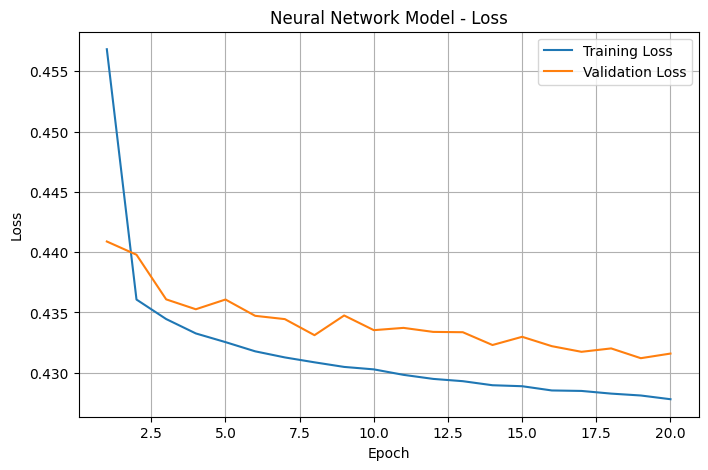

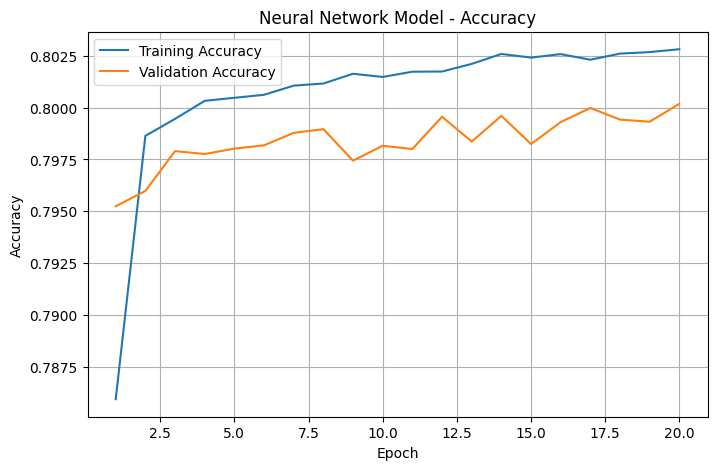

In [11]:
plot_history(history, "Neural Network Model")

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

In [12]:
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

# it splits data into raw and combined
X_Train_raw = X_Train[:, 0:8]
X_Test_raw = X_Test[:, 0:8]

X_Train_features = X_Train[:, 8:]
X_Test_features = X_Test[:, 8:]

X_Train_all = X_Train
X_Test_all = X_Test


def build_dnn(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


      # Trains rawfeature model
model_raw = build_dnn(X_Train_raw.shape[1])
history_raw = model_raw.fit(
    X_Train_raw, y_Train,
    validation_data=(X_Test_raw, y_Test),
    epochs=20,
    batch_size=256,
    verbose=1
)

  # Trains engineered feature model
model_features = build_dnn(X_Train_features.shape[1])
history_features = model_features.fit(
    X_Train_features, y_Train,
    validation_data=(X_Test_features, y_Test),
    epochs=20,
    batch_size=256,
    verbose=1
)

 # Trains combined model
model_all = build_dnn(X_Train_all.shape[1])
history_all = model_all.fit(
    X_Train_all, y_Train,
    validation_data=(X_Test_all, y_Test),
    epochs=20,
    batch_size=256,
    verbose=1
)

# In this section, I prepare different feature sets and train neural network models to compare their performance


Epoch 1/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 291us/step - accuracy: 0.7717 - loss: 0.4799 - val_accuracy: 0.7818 - val_loss: 0.4636
Epoch 2/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 265us/step - accuracy: 0.7859 - loss: 0.4580 - val_accuracy: 0.7853 - val_loss: 0.4567
Epoch 3/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 270us/step - accuracy: 0.7885 - loss: 0.4530 - val_accuracy: 0.7887 - val_loss: 0.4523
Epoch 4/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 269us/step - accuracy: 0.7904 - loss: 0.4501 - val_accuracy: 0.7888 - val_loss: 0.4505
Epoch 5/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 265us/step - accuracy: 0.7916 - loss: 0.4481 - val_accuracy: 0.7895 - val_loss: 0.4484
Epoch 6/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 268us/step - accuracy: 0.7926 - loss: 0.4461 - val_accuracy: 0.7909 - val_loss: 0.4469
Epoch 7/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 270us/step - accuracy: 0.7934 - loss: 0.4445 - val_accuracy: 0.7916 - val_loss: 0.4459
Epoch 8/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 291us/step - accuracy: 0.7951 -

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 144us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 142us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 140us/step


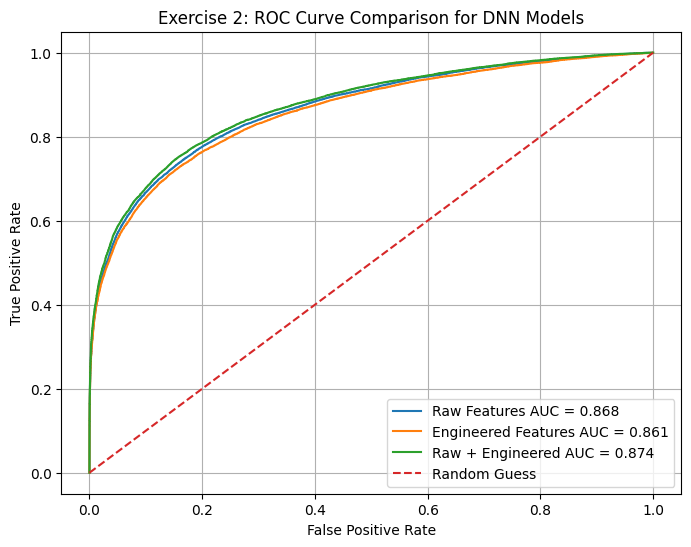

In [13]:

y_score_raw = model_raw.predict(X_Test_raw).ravel()
y_score_features = model_features.predict(X_Test_features).ravel()
y_score_all = model_all.predict(X_Test_all).ravel()

# Compute ROC curves
fpr_raw, tpr_raw, _ = roc_curve(y_Test, y_score_raw)
fpr_features, tpr_features, _ = roc_curve(y_Test, y_score_features)
fpr_all, tpr_all, _ = roc_curve(y_Test, y_score_all)

auc_raw = auc(fpr_raw, tpr_raw)
auc_features = auc(fpr_features, tpr_features)
auc_all = auc(fpr_all, tpr_all)

# Plots ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_raw, tpr_raw, label=f"Raw Features AUC = {auc_raw:.3f}")
plt.plot(fpr_features, tpr_features, label=f"Engineered Features AUC = {auc_features:.3f}")
plt.plot(fpr_all, tpr_all, label=f"Raw + Engineered AUC = {auc_all:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Exercise 2: ROC Curve Comparison for DNN Models")
plt.legend() 
plt.grid(True)
plt.show()
# Here, I evaluate the trained models by computing ROC curves and AUC values to compare their classification performance

The ROC curves show Dnn models trained with raw variables and engineered features, and their combination. The AUC is the area under the curve which indicates the model's ability to distinguish between signal and background. The larger the AUC, the better the model's performance. The model that uses both raw and engineered features is expected to be the best one as it uses all the available information in the data.

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

In [15]:
model1 = Sequential([
    Input(shape=(X_Train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history1 = model1.fit(
    X_Train, y_Train,
    validation_data=(X_Test, y_Test),
    epochs=20,
    batch_size=256,
    verbose=1
)
# This is a simple model with one hidden layer to see how a basic network performs

Epoch 1/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 274us/step - accuracy: 0.7700 - loss: 0.4859 - val_accuracy: 0.7916 - val_loss: 0.4512
Epoch 2/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 0s 247us/step - accuracy: 0.7962 - loss: 0.4435 - val_accuracy: 0.7949 - val_loss: 0.4431
Epoch 3/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 257us/step - accuracy: 0.7978 - loss: 0.4390 - val_accuracy: 0.7963 - val_loss: 0.4404
Epoch 4/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 0s 248us/step - accuracy: 0.7986 - loss: 0.4373 - val_accuracy: 0.7963 - val_loss: 0.4400
Epoch 5/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 0s 247us/step - accuracy: 0.7995 - loss: 0.4361 - val_accuracy: 0.7968 - val_loss: 0.4393
Epoch 6/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 0s 251us/step - accuracy: 0.7996 - loss: 0.4354 - val_accuracy: 0.7979 - val_loss: 0.4377
Epoch 7/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 0s 250us/step - accuracy: 0.7997 - loss: 0.4346 - val_accuracy: 0.7984 - val_loss: 0.4367
Epoch 8/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 264us/step - accuracy: 0.7999 -

In [16]:
model2 = Sequential([
    Input(shape=(X_Train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history2 = model2.fit(
    X_Train, y_Train,
    validation_data=(X_Test, y_Test),
    epochs=20,
    batch_size=256,
    verbose=1
)
# Here I add another layer to make the model a bit more complex and see if performance improves

Epoch 1/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 301us/step - accuracy: 0.7885 - loss: 0.4544 - val_accuracy: 0.7958 - val_loss: 0.4412
Epoch 2/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 273us/step - accuracy: 0.7985 - loss: 0.4362 - val_accuracy: 0.7971 - val_loss: 0.4385
Epoch 3/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 274us/step - accuracy: 0.7997 - loss: 0.4343 - val_accuracy: 0.7970 - val_loss: 0.4362
Epoch 4/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 284us/step - accuracy: 0.8003 - loss: 0.4331 - val_accuracy: 0.7979 - val_loss: 0.4366
Epoch 5/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 272us/step - accuracy: 0.8006 - loss: 0.4322 - val_accuracy: 0.7954 - val_loss: 0.4377
Epoch 6/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 272us/step - accuracy: 0.8009 - loss: 0.4315 - val_accuracy: 0.7969 - val_loss: 0.4363
Epoch 7/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 270us/step - accuracy: 0.8015 - loss: 0.4310 - val_accuracy: 0.7972 - val_loss: 0.4353
Epoch 8/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 269us/step - accuracy: 0.8015 -

In [17]:
model3 = Sequential([
    Input(shape=(X_Train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history3 = model3.fit(
    X_Train, y_Train,
    validation_data=(X_Test, y_Test),
    epochs=20,
    batch_size=256,
    verbose=1
)
# This model is deeper with more layers to capture more complex patterns in the data

Epoch 1/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 350us/step - accuracy: 0.7923 - loss: 0.4473 - val_accuracy: 0.7965 - val_loss: 0.4379
Epoch 2/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 322us/step - accuracy: 0.7990 - loss: 0.4351 - val_accuracy: 0.7972 - val_loss: 0.4361
Epoch 3/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 321us/step - accuracy: 0.8003 - loss: 0.4331 - val_accuracy: 0.7975 - val_loss: 0.4343
Epoch 4/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 329us/step - accuracy: 0.8010 - loss: 0.4317 - val_accuracy: 0.7972 - val_loss: 0.4361
Epoch 5/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 336us/step - accuracy: 0.8011 - loss: 0.4310 - val_accuracy: 0.7989 - val_loss: 0.4333
Epoch 6/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 341us/step - accuracy: 0.8014 - loss: 0.4303 - val_accuracy: 0.7997 - val_loss: 0.4320
Epoch 7/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 324us/step - accuracy: 0.8018 - loss: 0.4298 - val_accuracy: 0.7972 - val_loss: 0.4337
Epoch 8/20
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 1s 326us/step - accuracy: 0.8022 -

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 142us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 141us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 147us/step


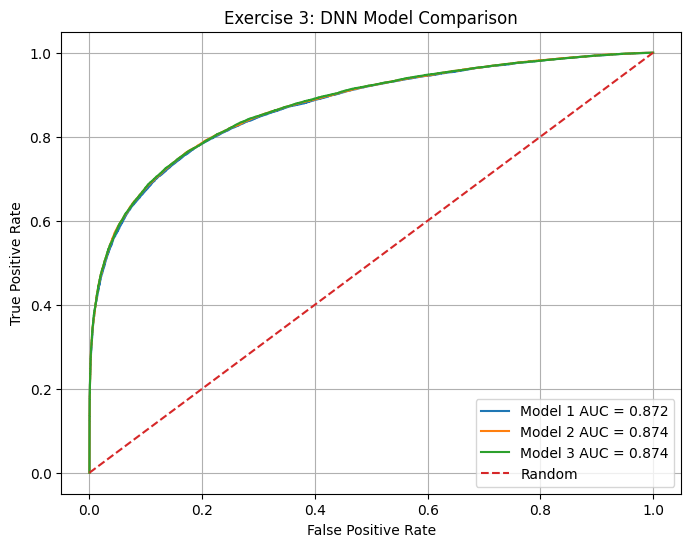

In [18]:
from sklearn.metrics import roc_curve, auc

#  Prediction
y1 = model1.predict(X_Test).ravel()
y2 = model2.predict(X_Test).ravel()
y3 = model3.predict(X_Test).ravel()

# ROC
fpr1, tpr1, _ = roc_curve(y_Test, y1)
fpr2, tpr2, _ = roc_curve(y_Test, y2)
fpr3, tpr3, _ = roc_curve(y_Test, y3)

# AUC
auc1 = auc(fpr1, tpr1)
auc2 = auc(fpr2, tpr2)
auc3 = auc(fpr3, tpr3)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr1, tpr1, label=f"Model 1 AUC = {auc1:.3f}")
plt.plot(fpr2, tpr2, label=f"Model 2 AUC = {auc2:.3f}")
plt.plot(fpr3, tpr3, label=f"Model 3 AUC = {auc3:.3f}")
plt.plot([0,1],[0,1],'--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Exercise 3: DNN Model Comparison")
plt.legend()
plt.grid(True)
plt.show()

# Here I compare all the models using ROC curves to see which one separates signal and background the best

## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Train traditional models
log_model = LogisticRegression(max_iter=1000)
tree_model = DecisionTreeClassifier(max_depth=10, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

log_model.fit(X_Train, y_Train)
tree_model.fit(X_Train, y_Train)
rf_model.fit(X_Train, y_Train)

# Get prediction probabilities
log_score = log_model.predict_proba(X_Test)[:, 1]
tree_score = tree_model.predict_proba(X_Test)[:, 1]
rf_score = rf_model.predict_proba(X_Test)[:, 1]

# Using  best DNN from Exercise 3
dnn_score = model3.predict(X_Test).ravel()
 Here I compare traditional machine learning models from Lab 8 with my best DNN model from Exercise 3

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 142us/step


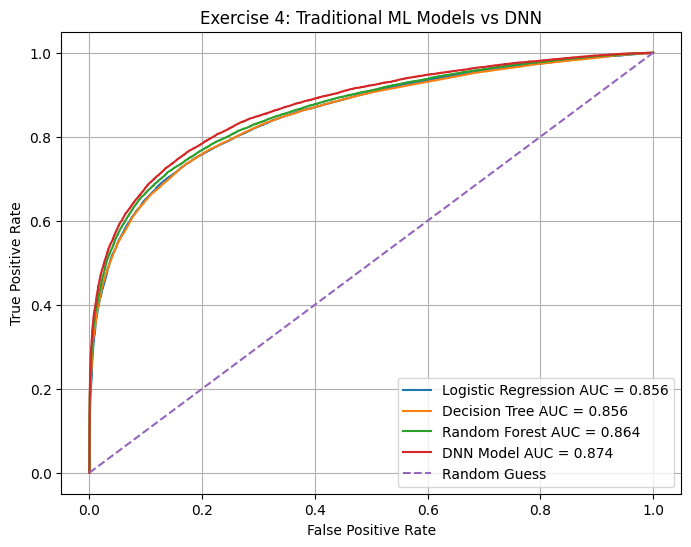

In [24]:
# I use ROC curves and AUC values to compare how well each model separates signal from background
#Compute ROC curves
fpr_log, tpr_log, _ = roc_curve(y_Test, log_score)
fpr_tree, tpr_tree, _ = roc_curve(y_Test, tree_score)
fpr_rf, tpr_rf, _ = roc_curve(y_Test, rf_score)
fpr_dnn, tpr_dnn, _ = roc_curve(y_Test, dnn_score)

# Compute AUC values
auc_log = auc(fpr_log, tpr_log)
auc_tree = auc(fpr_tree, tpr_tree)
auc_rf = auc(fpr_rf, tpr_rf)
auc_dnn = auc(fpr_dnn, tpr_dnn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression AUC = {auc_log:.3f}")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree AUC = {auc_tree:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {auc_rf:.3f}")
plt.plot(fpr_dnn, tpr_dnn, label=f"DNN Model AUC = {auc_dnn:.3f}")

plt.plot([0, 1], [0, 1], "--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Exercise 4: Traditional ML Models vs DNN")
plt.legend()
plt.grid(True)
plt.show()

The ROC curves compare traditional machine learning models with the best DNN model from Exercise 3. The DNN model performs very well because it can learn nonlinear patterns in the data. However, the comparison shows whether the added complexity of a neural network gives a significant improvement over simpler models such as logistic regression, decision trees, or random forests.